In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gibbs_script import SparseTobitGibbs

input_folder = "simulations/X_design/scenario_1_22"

X = np.load(f"{input_folder}/X.npy")
n,d = X.shape
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u,  sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

n_iter = 1500
burn_in = 500

tau2 = 0.05
pi0 = 0.033

model_gibbs = SparseTobitGibbs(
    X, y,
    tau2 = tau2,
    pi0 = pi0,
    seed = 42,
)

beta_samples, gamma_samples, sigma_samples = model_gibbs.fit(
    n_iter = burn_in + n_iter, 
    burn_in = 0, 
    gamma_batch_size = 1
)

samples = {
    "beta": beta_samples,
    "gamma": gamma_samples,
    "sigma": sigma_samples
}

Gibbs: 100%|██████████| 2000/2000 [00:09<00:00, 205.21it/s]


/localhome/mpieczar/tmp/ipykernel_3248165/2351781980.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.94])


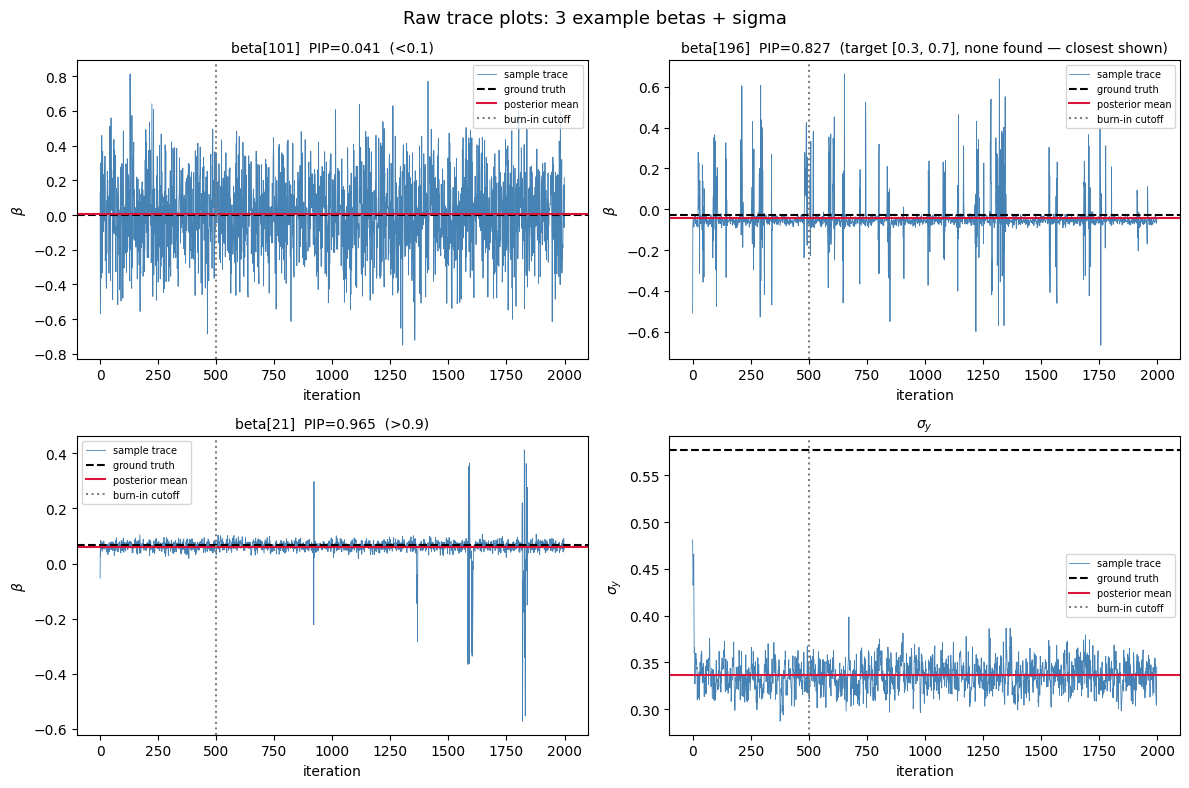

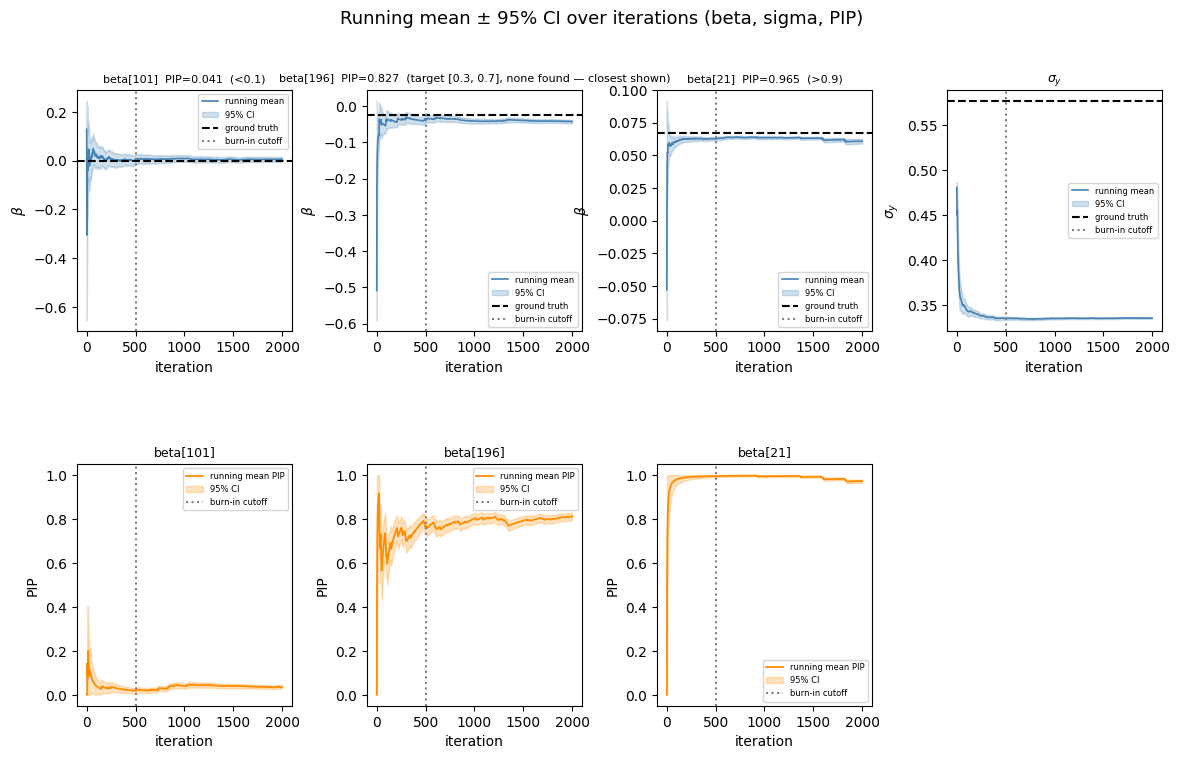

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Ground truth
# ------------------------------------------------------------------
beta_true = np.load(f"{input_folder}/beta.npy")

# ------------------------------------------------------------------
# Posterior Inclusion Probability (PIP) and selection of example betas
# PIP is computed on post-burn-in samples of gamma (inclusion indicator)
# ------------------------------------------------------------------
post_burn_gamma = gamma_samples[burn_in:]
pip = post_burn_gamma.mean(axis=0)  # (d,) PIP per feature


def pick_index(mask, target):
    """Pick the feature index satisfying `mask` whose PIP is closest to
    `target`. Falls back to the globally closest PIP if no index
    satisfies the mask (e.g. no feature happens to have PIP in the
    requested range). Returns (index, exact_match_bool) so the caller
    can be honest about whether the requested condition was actually met.
    """
    candidates = np.where(mask)[0]
    if len(candidates) == 0:
        return int(np.argmin(np.abs(pip - target))), False
    return int(candidates[np.argmin(np.abs(pip[candidates] - target))]), True


idx_low, ok_low = pick_index(pip < 0.1, target=0.05)
idx_mid, ok_mid = pick_index((pip >= 0.3) & (pip <= 0.7), target=0.5)
idx_high, ok_high = pick_index(pip > 0.9, target=0.95)

for name, ok, condition in [
    ("low (<0.1)", ok_low, "PIP < 0.1"),
    ("mid ([0.3, 0.7])", ok_mid, "0.3 <= PIP <= 0.7"),
    ("high (>0.9)", ok_high, "PIP > 0.9"),
]:
    if not ok:
        print(f"WARNING: no beta satisfies '{condition}' ({name}); "
              f"showing closest available PIP instead.")

beta_idx = [idx_low, idx_mid, idx_high]


def make_label(idx, ok, condition_text):
    tag = condition_text if ok else f"target {condition_text}, none found \u2014 closest shown"
    return f"beta[{idx}]  PIP={pip[idx]:.3f}  ({tag})"


beta_labels = [
    make_label(idx_low, ok_low, "<0.1"),
    make_label(idx_mid, ok_mid, "[0.3, 0.7]"),
    make_label(idx_high, ok_high, ">0.9"),
]

iters = np.arange(beta_samples.shape[0])

# ==================================================================
# Figure 1: raw trace plots (4 panels: 3 example betas + sigma)
# ==================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))
axes1 = axes1.ravel()

for ax, idx, label in zip(axes1[:3], beta_idx, beta_labels):
    trace = beta_samples[:, idx]
    post_mean = trace[burn_in:].mean()
    ax.plot(iters, trace, lw=0.6, color="steelblue", label="sample trace")
    ax.axhline(beta_true[idx], color="black", ls="--", lw=1.5, label="ground truth")
    ax.axhline(post_mean, color="crimson", ls="-", lw=1.5, label="posterior mean")
    ax.axvline(burn_in, color="grey", ls=":", lw=1.5, label="burn-in cutoff")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$\beta$")
    ax.legend(fontsize=7)

ax_sigma = axes1[3]
sigma_post_mean = sigma_samples[burn_in:].mean()
ax_sigma.plot(iters, sigma_samples, lw=0.6, color="steelblue", label="sample trace")
ax_sigma.axhline(sigma_y_true, color="black", ls="--", lw=1.5, label="ground truth")
ax_sigma.axhline(sigma_post_mean, color="crimson", ls="-", lw=1.5, label="posterior mean")
ax_sigma.axvline(burn_in, color="grey", ls=":", lw=1.5, label="burn-in cutoff")
ax_sigma.set_title(r"$\sigma_y$", fontsize=10)
ax_sigma.set_xlabel("iteration")
ax_sigma.set_ylabel(r"$\sigma_y$")
ax_sigma.legend(fontsize=7)

fig1.suptitle("Raw trace plots: 3 example betas + sigma", fontsize=13)
fig1.tight_layout()
fig1.savefig(f"{input_folder}/trace_plots_raw.png", dpi=150)


# ------------------------------------------------------------------
# Helper: cumulative (running) mean and 95% CI half-width.
# CI is based on the Monte Carlo standard error of the running mean,
# se = running_std / sqrt(n), so (unlike a raw +/- std band) it
# shrinks as n grows -- this is what illustrates convergence.
# Note: treats samples as i.i.d.; with strong MCMC autocorrelation
# the true effective sample size is smaller than n, so the interval
# is optimistic, but it is still useful to visualize the shrinking
# trend.
# ------------------------------------------------------------------
Z_95 = 1.959963984540054


def running_mean_ci(x, z=Z_95):
    x = np.asarray(x, dtype=float)
    n = np.arange(1, len(x) + 1)
    running_mean = np.cumsum(x) / n
    running_var = np.cumsum(x ** 2) / n - running_mean ** 2
    running_var = np.clip(running_var, 0, None)
    se = np.sqrt(running_var / n)
    return running_mean, z * se


# ==================================================================
# Figure 2:
#   - top row (4 panels): running mean +/- 95% CI for the 3 example
#     betas and sigma
#   - bottom row (3 panels): running PIP mean +/- 95% CI
#   In both rows the CI half-width shrinks with n, visualizing MCMC
#   convergence.
# ==================================================================
fig2 = plt.figure(figsize=(14, 8))
gs = fig2.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.55, wspace=0.35)

top_axes = [fig2.add_subplot(gs[0, j]) for j in range(4)]

for ax, idx, label in zip(top_axes[:3], beta_idx, beta_labels):
    trace = beta_samples[:, idx]
    rmean, ci = running_mean_ci(trace)
    ax.plot(iters, rmean, color="steelblue", lw=1.2, label="running mean")
    ax.fill_between(iters, rmean - ci, rmean + ci, color="steelblue",
                     alpha=0.25, label="95% CI")
    ax.axhline(beta_true[idx], color="black", ls="--", lw=1.5, label="ground truth")
    ax.axvline(burn_in, color="grey", ls=":", lw=1.5, label="burn-in cutoff")
    ax.set_title(label, fontsize=8, wrap=True)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$\beta$")
    ax.legend(fontsize=6)

rmean_s, ci_s = running_mean_ci(sigma_samples)
ax = top_axes[3]
ax.plot(iters, rmean_s, color="steelblue", lw=1.2, label="running mean")
ax.fill_between(iters, rmean_s - ci_s, rmean_s + ci_s, color="steelblue",
                 alpha=0.25, label="95% CI")
ax.axhline(sigma_y_true, color="black", ls="--", lw=1.5, label="ground truth")
ax.axvline(burn_in, color="grey", ls=":", lw=1.5, label="burn-in cutoff")
ax.set_title(r"$\sigma_y$", fontsize=9)
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\sigma_y$")
ax.legend(fontsize=6)

pip_axes = [fig2.add_subplot(gs[1, j]) for j in range(3)]

for ax, idx in zip(pip_axes, beta_idx):
    gtrace = gamma_samples[:, idx].astype(float)
    rmean_g, ci_g = running_mean_ci(gtrace)

    ax.plot(iters, rmean_g, color="darkorange", lw=1.3, label="running mean PIP")
    ax.fill_between(iters, np.clip(rmean_g - ci_g, 0, 1), np.clip(rmean_g + ci_g, 0, 1),
                     color="darkorange", alpha=0.25, label="95% CI")
    ax.axvline(burn_in, color="grey", ls=":", lw=1.5, label="burn-in cutoff")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"beta[{idx}]", fontsize=9)
    ax.set_xlabel("iteration")
    ax.set_ylabel("PIP")
    ax.legend(fontsize=6)

fig2.suptitle("Running mean \u00b1 95% CI over iterations (beta, sigma, PIP)", fontsize=13)
fig2.tight_layout(rect=[0, 0, 1, 0.94])
fig2.savefig(f"{input_folder}/trace_plots_running.png", dpi=150)

plt.show()

In [7]:
"""
Compute the multivariate PSRF (MPSRF, Brooks & Gelman 1998) for the beta
chain produced by SparseTobitGibbs, based on several parallel chains
started from different seeds.

R_p = (n-1)/n + (1 + 1/m) * lambda1

where lambda1 is the largest eigenvalue of the generalized eigenvalue
problem  B* v = lambda * W* v
(W* = within-chain covariance matrix, B*/n = between-chain-mean covariance
matrix, as defined in Brooks & Gelman 1998 / Roy 2020 review, Eq. 8).
"""

import numpy as np
from scipy.linalg import eig
from gibbs_script import SparseTobitGibbs

# ---------------------------------------------------------------
# Config
# ---------------------------------------------------------------
input_folder = "simulations/X_design/scenario_1_22"

n_iter = 2000
burn_in = 500          # discard burn-in before computing MPSRF
n_chains = 4            # m >= 2 parallel chains required
seeds = [42, 123, 2024, 7]  # one seed per chain; different starting points

tau2 = 0.033
pi0 = 0.04

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
X = np.load(f"{input_folder}/X.npy")
n, d = X.shape
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

# ---------------------------------------------------------------
# Run parallel chains
# ---------------------------------------------------------------
beta_chains = []  # list of (n_iter - burn_in, d) arrays, one per chain

for seed in seeds[:n_chains]:
    model = SparseTobitGibbs(
        X, y,
        tau2=tau2,
        pi0=pi0,
        seed=seed,
    )
    beta_samples, gamma_samples, sigma_samples = model.fit(
        n_iter=n_iter,
        burn_in=0,
        gamma_batch_size=1,
    )
    beta_post_burnin = beta_samples[burn_in:]  # (n_iter - burn_in, d)
    beta_chains.append(beta_post_burnin)
    print(f"Chain seed={seed}: {beta_post_burnin.shape[0]} post-burn-in samples")

# ---------------------------------------------------------------
# MPSRF computation (Brooks & Gelman 1998)
# ---------------------------------------------------------------
def compute_mpsrf(chains):
    """
    chains: list of m arrays, each of shape (n, p) -- same n and p for all chains.
    Returns the scalar MPSRF (R_p).
    """
    m = len(chains)
    n_len = chains[0].shape[0]
    p = chains[0].shape[1]

    # within-chain covariance W* : average of per-chain sample covariances
    chain_covs = [np.cov(chain, rowvar=False, ddof=1) for chain in chains]
    W_star = np.mean(chain_covs, axis=0)  # (p, p)

    # between-chain-mean covariance B*/n : covariance of the m chain means
    chain_means = np.array([chain.mean(axis=0) for chain in chains])  # (m, p)
    B_over_n = np.cov(chain_means, rowvar=False, ddof=1)  # (p, p)

    # generalized eigenvalue problem: B*/n * v = lambda * W* * v
    eigvals, _ = eig(B_over_n, W_star)
    lambda1 = np.max(eigvals.real)

    R_p = (n_len - 1) / n_len + (1 + 1 / m) * lambda1
    return R_p, lambda1


mpsrf, lambda1 = compute_mpsrf(beta_chains)

print("\n--- MPSRF results ---")
print(f"Number of chains (m): {n_chains}")
print(f"Samples per chain after burn-in: {beta_chains[0].shape[0]}")
print(f"Dimension of beta (p): {d}")
print(f"Largest eigenvalue (lambda1): {lambda1:.4f}")
print(f"MPSRF (R_p): {mpsrf:.4f}")

if mpsrf < 1.1:
    print("MPSRF < 1.1: no strong evidence against convergence (joint check).")
else:
    print("MPSRF >= 1.1: chains have likely not converged jointly yet.")

Gibbs: 100%|██████████| 2000/2000 [00:10<00:00, 191.58it/s]


Chain seed=42: 1500 post-burn-in samples


Gibbs: 100%|██████████| 2000/2000 [00:10<00:00, 193.16it/s]


Chain seed=123: 1500 post-burn-in samples


Gibbs: 100%|██████████| 2000/2000 [00:10<00:00, 193.62it/s]


Chain seed=2024: 1500 post-burn-in samples


Gibbs: 100%|██████████| 2000/2000 [00:10<00:00, 195.80it/s]


Chain seed=7: 1500 post-burn-in samples

--- MPSRF results ---
Number of chains (m): 4
Samples per chain after burn-in: 1500
Dimension of beta (p): 201
Largest eigenvalue (lambda1): 0.0534
MPSRF (R_p): 1.0661
MPSRF < 1.1: no strong evidence against convergence (joint check).


In [8]:
"""
Check agreement of gamma (variable-inclusion indicator) patterns across
several parallel Gibbs chains.

Complements compute_mpsrf.py: MPSRF on beta alone can look fine even if
different chains have settled on different active-variable subsets
(a common failure mode under strong sparsity priors, cf. multimodal
example in Roy 2020).

Three diagnostics are computed:
  1. Posterior inclusion probability (PIP) per chain, and pairwise
     correlation / max abs difference between chains' PIP vectors.
  2. Jaccard similarity of "selected" variable sets (PIP > threshold)
     between each pair of chains.
  3. Per-variable PSRF (R-hat) treating gamma as a continuous 0/1 series
     -- flags individual variables with poor mixing/agreement even when
     the aggregate MPSRF looks fine.
"""

import numpy as np
from itertools import combinations
from gibbs_script import SparseTobitGibbs

# ---------------------------------------------------------------
# Config (reuse same setup as compute_mpsrf.py)
# ---------------------------------------------------------------
input_folder = "simulations/X_design/scenario_1_22"

n_iter = 1000
burn_in = 500
n_chains = 4
seeds = [42, 123, 2024, 7]

tau2 = 0.05
pi0 = 0.033

selection_threshold = 0.5  # PIP threshold to call a variable "active"

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
X = np.load(f"{input_folder}/X.npy")
n, d = X.shape
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

# ---------------------------------------------------------------
# Run parallel chains, keep gamma samples
# ---------------------------------------------------------------
gamma_chains = []  # list of (n_iter - burn_in, d) 0/1 arrays

for seed in seeds[:n_chains]:
    model = SparseTobitGibbs(
        X, y,
        tau2=tau2,
        pi0=pi0,
        seed=seed,
    )
    beta_samples, gamma_samples, sigma_samples = model.fit(
        n_iter=n_iter,
        burn_in=0,
        gamma_batch_size=1,
    )
    gamma_chains.append(gamma_samples[burn_in:])
    print(f"Chain seed={seed}: {gamma_chains[-1].shape[0]} post-burn-in samples")

m = len(gamma_chains)

# ---------------------------------------------------------------
# 1. Posterior inclusion probabilities (PIP) per chain
# ---------------------------------------------------------------
pips = np.array([chain.mean(axis=0) for chain in gamma_chains])  # (m, d)

print("\n--- Posterior inclusion probabilities (PIP) ---")
for i, seed in enumerate(seeds[:n_chains]):
    n_active = (pips[i] > selection_threshold).sum()
    print(f"Chain seed={seed}: {n_active} variables with PIP > {selection_threshold}")

pip_corr = np.corrcoef(pips)  # (m, m)
print("\nPairwise correlation between chains' PIP vectors:")
print(np.round(pip_corr, 3))

max_abs_diff = np.zeros((m, m))
for i, j in combinations(range(m), 2):
    max_abs_diff[i, j] = max_abs_diff[j, i] = np.max(np.abs(pips[i] - pips[j]))
print("\nMax |PIP_i - PIP_j| per chain pair:")
print(np.round(max_abs_diff, 3))

# ---------------------------------------------------------------
# 2. Jaccard similarity of selected-variable sets
# ---------------------------------------------------------------
selected_sets = [set(np.where(pips[i] > selection_threshold)[0]) for i in range(m)]

print(f"\n--- Jaccard similarity of active-variable sets (PIP > {selection_threshold}) ---")
for i, j in combinations(range(m), 2):
    inter = len(selected_sets[i] & selected_sets[j])
    union = len(selected_sets[i] | selected_sets[j])
    jaccard = inter / union if union > 0 else 1.0
    print(f"Chain {seeds[i]} vs {seeds[j]}: Jaccard = {jaccard:.3f} "
          f"({inter} shared / {union} total active)")

# ---------------------------------------------------------------
# 3. Per-variable PSRF (gamma treated as continuous 0/1)
# ---------------------------------------------------------------
def per_variable_psrf(chains):
    """
    chains: list of m arrays, each (n, d).
    Returns array of shape (d,) with the standard (univariate) PSRF
    for each column, computed across the m chains.
    """
    m = len(chains)
    n_len = chains[0].shape[0]
    d_dim = chains[0].shape[1]

    chain_means = np.array([c.mean(axis=0) for c in chains])       # (m, d)
    chain_vars = np.array([c.var(axis=0, ddof=1) for c in chains])  # (m, d)

    W = chain_vars.mean(axis=0)                       # (d,) within-chain variance
    B_over_n = chain_means.var(axis=0, ddof=1)         # (d,) between-chain-mean variance
    V_hat = ((n_len - 1) / n_len) * W + B_over_n

    with np.errstate(divide="ignore", invalid="ignore"):
        R_hat = np.where(W > 0, V_hat / W, 1.0)
    return R_hat


R_hat_gamma = per_variable_psrf(gamma_chains)

print("\n--- Per-variable PSRF for gamma ---")
worst_idx = np.argsort(-R_hat_gamma)[:10]
print("Top 10 variables with highest (worst) PSRF:")
for idx in worst_idx:
    print(f"  variable {idx}: R_hat = {R_hat_gamma[idx]:.3f}, "
          f"PIP per chain = {np.round(pips[:, idx], 3)}")

n_bad = (R_hat_gamma > 1.1).sum()
print(f"\nVariables with PSRF > 1.1: {n_bad} / {d}")

Gibbs: 100%|██████████| 1000/1000 [00:05<00:00, 194.88it/s]


Chain seed=42: 500 post-burn-in samples


Gibbs: 100%|██████████| 1000/1000 [00:05<00:00, 193.65it/s]


Chain seed=123: 500 post-burn-in samples


Gibbs: 100%|██████████| 1000/1000 [00:05<00:00, 195.27it/s]


Chain seed=2024: 500 post-burn-in samples


Gibbs: 100%|██████████| 1000/1000 [00:05<00:00, 194.82it/s]


Chain seed=7: 500 post-burn-in samples

--- Posterior inclusion probabilities (PIP) ---
Chain seed=42: 19 variables with PIP > 0.5
Chain seed=123: 19 variables with PIP > 0.5
Chain seed=2024: 19 variables with PIP > 0.5
Chain seed=7: 19 variables with PIP > 0.5

Pairwise correlation between chains' PIP vectors:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Max |PIP_i - PIP_j| per chain pair:
[[0.    0.076 0.04  0.046]
 [0.076 0.    0.062 0.074]
 [0.04  0.062 0.    0.062]
 [0.046 0.074 0.062 0.   ]]

--- Jaccard similarity of active-variable sets (PIP > 0.5) ---
Chain 42 vs 123: Jaccard = 1.000 (19 shared / 19 total active)
Chain 42 vs 2024: Jaccard = 1.000 (19 shared / 19 total active)
Chain 42 vs 7: Jaccard = 1.000 (19 shared / 19 total active)
Chain 123 vs 2024: Jaccard = 1.000 (19 shared / 19 total active)
Chain 123 vs 7: Jaccard = 1.000 (19 shared / 19 total active)
Chain 2024 vs 7: Jaccard = 1.000 (19 shared / 19 total active)

--- Per-variable PSRF for gamma ---
T

In [13]:
"""
Compute univariate ESS per beta component (safe alternative to
multivariate mESS when p is comparable to or larger than the number of
batches available for covariance estimation -- see compute_mess.py note).

ESS_j = n / (1 + 2 * sum_{k=1}^{K} rho_k(j))

where rho_k(j) is the lag-k autocorrelation of the j-th beta component,
estimated via the empirical autocorrelation function (FFT-based) and
summed until autocorrelations become negative (Geyer's initial positive
sequence rule) to avoid noise in the tail from inflating the estimate.
"""

import numpy as np
from gibbs_script import SparseTobitGibbs

# ---------------------------------------------------------------
# Config (reuse same setup as compute_mpsrf.py)
# ---------------------------------------------------------------
input_folder = "simulations/X_design/scenario_1_22"

n_iter = 1500
burn_in = 500
n_chains = 4
seeds = [42, 123, 2024, 7]

tau2 = 0.05
pi0 = 0.033

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
X = np.load(f"{input_folder}/X.npy")
n, d = X.shape
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

# ---------------------------------------------------------------
# Run parallel chains, keep beta samples
# ---------------------------------------------------------------
beta_chains = []

for seed in seeds[:n_chains]:
    model = SparseTobitGibbs(
        X, y,
        tau2=tau2,
        pi0=pi0,
        seed=seed,
    )
    beta_samples, gamma_samples, sigma_samples = model.fit(
        n_iter=n_iter,
        burn_in=0,
        gamma_batch_size=1,
    )
    beta_chains.append(beta_samples[burn_in:])

p = beta_chains[0].shape[1]

# ---------------------------------------------------------------
# Univariate ESS via Geyer's initial positive sequence
# ---------------------------------------------------------------
def autocorr_fft(x):
    """Full autocorrelation function of a 1D series via FFT."""
    n_len = len(x)
    x = x - x.mean()
    fsize = 2 ** int(np.ceil(np.log2(2 * n_len - 1)))
    Xf = np.fft.fft(x, fsize)
    acf = np.fft.ifft(Xf * np.conjugate(Xf)).real[:n_len]
    acf /= acf[0]
    return acf


def ess_1d(x):
    n_len = len(x)
    acf = autocorr_fft(x)
    # Geyer's initial positive sequence: sum paired lags until they turn negative
    rho_sum = 0.0
    k = 1
    while k + 1 < n_len:
        pair_sum = acf[k] + acf[k + 1]
        if pair_sum < 0:
            break
        rho_sum += pair_sum
        k += 2
    denom = 1 + 2 * rho_sum
    return n_len / denom if denom > 0 else np.nan


# ---------------------------------------------------------------
# Report per-variable ESS, aggregated across chains
# ---------------------------------------------------------------
print("--- Univariate ESS per beta component ---")
print(f"Dimension p = {p}, samples per chain n = {beta_chains[0].shape[0]}\n")

all_ess = np.zeros((n_chains, p))
for i, chain in enumerate(beta_chains):
    for j in range(p):
        all_ess[i, j] = ess_1d(chain[:, j])

min_ess_per_var = all_ess.min(axis=0)   # worst chain, per variable
worst_vars = np.argsort(min_ess_per_var)[:10]

print("10 variables with lowest ESS (worst mixing), min across chains:")
for idx in worst_vars:
    print(f"  variable {idx}: min ESS = {min_ess_per_var[idx]:,.1f} "
          f"(per-chain: {np.round(all_ess[:, idx], 1)})")

print(f"\nOverall minimum ESS (any variable, any chain): {all_ess.min():,.1f}")
print(f"Overall median ESS: {np.median(all_ess):,.1f}")
print(f"Overall mean ESS: {all_ess.mean():,.1f}")
print(f"Number of samples per chain: {beta_chains[0].shape[0]}")

Gibbs: 100%|██████████| 1500/1500 [00:07<00:00, 205.33it/s]

--- Univariate ESS per beta component ---
Dimension p = 201, samples per chain n = 1000

10 variables with lowest ESS (worst mixing), min across chains:
  variable 167: min ESS = 326.1 (per-chain: [742.8 636.5 834.1 326.1])
  variable 123: min ESS = 371.8 (per-chain: [608.5 603.7 371.8 545.4])
  variable 116: min ESS = 385.5 (per-chain: [630.5 385.5 906.4 711. ])
  variable 158: min ESS = 427.5 (per-chain: [639.3 630.  497.3 427.5])
  variable 191: min ESS = 437.6 (per-chain: [457.  632.7 437.6 569.1])
  variable 22: min ESS = 445.1 (per-chain: [445.1 571.3 551.2 514.7])
  variable 122: min ESS = 465.4 (per-chain: [664.3 640.3 655.4 465.4])
  variable 21: min ESS = 466.4 (per-chain: [466.4 686.8 760.  661. ])
  variable 180: min ESS = 471.7 (per-chain: [471.7 544.4 566.6 494.3])
  variable 28: min ESS = 541.9 (per-chain: [621.2 541.9 648.2 609.7])

Overall minimum ESS (any variable, any chain): 326.1
Overall median ESS: 984.8
Overall mean ESS: 914.2
Number of samples per chain: 1000


Gibbs: 100%|██████████| 1500/1500 [00:07<00:00, 193.39it/s]


Chain seed=42: computed g_t for 1000 post-burn-in iterations (mean g = 4318.14, std = 203.01)


Gibbs: 100%|██████████| 1500/1500 [00:07<00:00, 199.26it/s]


Chain seed=123: computed g_t for 1000 post-burn-in iterations (mean g = 4311.88, std = 195.79)


Gibbs: 100%|██████████| 1500/1500 [00:07<00:00, 202.65it/s]


Chain seed=2024: computed g_t for 1000 post-burn-in iterations (mean g = 4329.68, std = 195.63)


Gibbs: 100%|██████████| 1500/1500 [00:07<00:00, 190.94it/s]


Chain seed=7: computed g_t for 1000 post-burn-in iterations (mean g = 4325.54, std = 202.98)


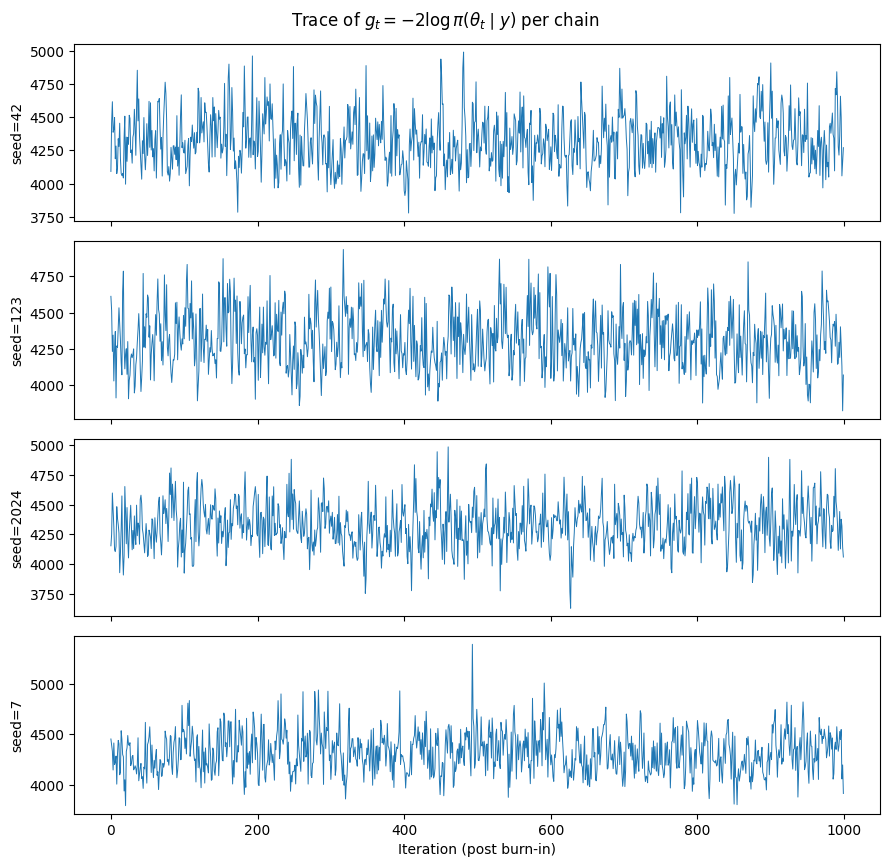


--- Generalized Geweke test (g = -2 log posterior) ---
Chain seed=42: Z = -0.054, p = 0.957  [pass]  (nA=100, nB=500)
Chain seed=123: Z = -0.134, p = 0.893  [pass]  (nA=100, nB=500)
Chain seed=2024: Z = -0.468, p = 0.640  [pass]  (nA=100, nB=500)
Chain seed=7: Z = -1.852, p = 0.064  [pass]  (nA=100, nB=500)


In [15]:
"""
Generalized (multivariate) Geweke test for the sparse Tobit Gibbs sampler.

Model:
  y_i = clip(y*_i; l, u)
  y* | beta, gamma, sigma2 ~ N(X Gamma beta, sigma2 I),  Gamma = diag(gamma)
  beta | tau2 ~ N(0, tau2 I)
  gamma_j ~ Bernoulli(pi0)
  sigma2 ~ InvGamma(eps, eps)

Since y* is latent (only y = clip(y*, l, u) is observed and not returned
by the sampler), the likelihood used here is the marginal Tobit
(censored) likelihood of y given (beta, gamma, sigma2), integrating out
y* analytically:
  - interior observations (l < y_i < u): Normal density
  - left-censored (y_i == l): Phi((l - mu_i) / sigma)
  - right-censored (y_i == u): 1 - Phi((u - mu_i) / sigma)

Then g_t = -2 * log p(beta_t, gamma_t, sigma2_t | y) (unnormalized
log-posterior, up to an additive constant that cancels in Geweke's
difference of means). Cowles & Carlin (1996) suggest exactly this choice
of g for a multivariate/generalized Geweke diagnostic (see Roy 2020
review, Section 2.5).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import gammaln
from gibbs_script import SparseTobitGibbs

# ---------------------------------------------------------------
# Config (reuse same setup as previous scripts)
# ---------------------------------------------------------------
input_folder = "simulations/X_design/scenario_1_22"

n_iter = 1500
burn_in = 500
n_chains = 4
seeds = [42, 123, 2024, 7]

tau2 = 0.05
pi0 = 0.033
eps = 1e-3  # ASSUMPTION: InvGamma(eps, eps) hyperparameter -- adjust if different

SIGMA_IS_VARIANCE = False  # ASSUMPTION: sigma_samples holds sigma (std), not sigma^2
                            # set True if your sampler returns sigma^2 directly

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
X = np.load(f"{input_folder}/X.npy")
n, d = X.shape
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()

interior_mask = (y > l) & (y < u)
left_mask = y <= l
right_mask = y >= u

# ---------------------------------------------------------------
# Unnormalized log-posterior
# ---------------------------------------------------------------
def log_posterior(beta, gamma, sigma_val, X, y, tau2, pi0, eps,
                   interior_mask, left_mask, right_mask, l, u,
                   sigma_is_variance=False):
    sigma2 = sigma_val if sigma_is_variance else sigma_val ** 2
    sigma = np.sqrt(sigma2)

    mu = X @ (gamma * beta)  # (n,)

    # --- Tobit (censored) log-likelihood ---
    ll = 0.0
    if interior_mask.any():
        resid = y[interior_mask] - mu[interior_mask]
        ll += np.sum(-0.5 * np.log(2 * np.pi * sigma2) - resid ** 2 / (2 * sigma2))
    if left_mask.any():
        z = (l - mu[left_mask]) / sigma
        ll += np.sum(norm.logcdf(z))
    if right_mask.any():
        z = (u - mu[right_mask]) / sigma
        ll += np.sum(norm.logsf(z))

    # --- log prior: beta | tau2 ~ N(0, tau2 I) ---
    d_dim = len(beta)
    lp_beta = -0.5 * d_dim * np.log(2 * np.pi * tau2) - np.sum(beta ** 2) / (2 * tau2)

    # --- log prior: gamma_j ~ Bernoulli(pi0) ---
    lp_gamma = np.sum(gamma * np.log(pi0) + (1 - gamma) * np.log(1 - pi0))

    # --- log prior: sigma2 ~ InvGamma(eps, eps) ---
    lp_sigma2 = (eps * np.log(eps) - gammaln(eps)
                 - (eps + 1) * np.log(sigma2) - eps / sigma2)

    return ll + lp_beta + lp_gamma + lp_sigma2


# ---------------------------------------------------------------
# Run parallel chains, compute g_t = -2 * log_posterior per iteration
# ---------------------------------------------------------------
g_chains = []

for seed in seeds[:n_chains]:
    model = SparseTobitGibbs(
        X, y,
        tau2=tau2,
        pi0=pi0,
        seed=seed,
    )
    beta_samples, gamma_samples, sigma_samples = model.fit(
        n_iter=n_iter,
        burn_in=0,
        gamma_batch_size=1,
    )
    beta_pb = beta_samples[burn_in:]
    gamma_pb = gamma_samples[burn_in:]
    sigma_pb = sigma_samples[burn_in:]

    n_post = beta_pb.shape[0]
    g_t = np.empty(n_post)
    for t in range(n_post):
        g_t[t] = -2 * log_posterior(
            beta_pb[t], gamma_pb[t], sigma_pb[t],
            X, y, tau2, pi0, eps,
            interior_mask, left_mask, right_mask, l, u,
            sigma_is_variance=SIGMA_IS_VARIANCE,
        )
    g_chains.append(g_t)
    print(f"Chain seed={seed}: computed g_t for {n_post} post-burn-in iterations "
          f"(mean g = {g_t.mean():.2f}, std = {g_t.std():.2f})")

# ---------------------------------------------------------------
# Trace plot of g_t for each chain
# ---------------------------------------------------------------
fig, axes = plt.subplots(n_chains, 1, figsize=(9, 2.2 * n_chains), sharex=True)
for i, (seed, g_t) in enumerate(zip(seeds[:n_chains], g_chains)):
    axes[i].plot(g_t, linewidth=0.7)
    axes[i].set_ylabel(f"seed={seed}")
axes[-1].set_xlabel("Iteration (post burn-in)")
fig.suptitle(r"Trace of $g_t = -2 \log \pi(\theta_t \mid y)$ per chain")
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Generalized (multivariate) Geweke test on g_t
# ---------------------------------------------------------------
def batch_means_var_of_mean(x):
    n_len = len(x)
    b = int(np.floor(np.sqrt(n_len)))
    l_ = n_len // b
    n_used = b * l_
    x = x[:n_used]
    batch_means = x.reshape(b, l_).mean(axis=1)
    overall_mean = x.mean()
    sigma_hat2 = (l_ / (b - 1)) * np.sum((batch_means - overall_mean) ** 2)
    return sigma_hat2 / n_used


def geweke_test(g_t, frac_a=0.1, frac_b=0.5):
    n_len = len(g_t)
    nA = int(frac_a * n_len)
    nB = int(frac_b * n_len)
    gA = g_t[:nA]
    gB = g_t[-nB:]
    varA = batch_means_var_of_mean(gA)
    varB = batch_means_var_of_mean(gB)
    Z = (gA.mean() - gB.mean()) / np.sqrt(varA + varB)
    return Z, nA, nB


print("\n--- Generalized Geweke test (g = -2 log posterior) ---")
for seed, g_t in zip(seeds[:n_chains], g_chains):
    Z, nA, nB = geweke_test(g_t)
    p_value = 2 * (1 - norm.cdf(abs(Z)))
    flag = "FAIL (|Z|>1.96)" if abs(Z) > 1.96 else "pass"
    print(f"Chain seed={seed}: Z = {Z:.3f}, p = {p_value:.3f}  [{flag}]  "
          f"(nA={nA}, nB={nB})")